In [3]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import compute_sample_weight
import warnings
import pickle as pkl
from glob import glob
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from ibl_info.decoder_utils import (
    congregate_data,
    collapse_animal,
    individual_region_means,
    pids_per_region,
)

from ibl_info.decoder_utils import (
    plot_all_rsis,
    plot_all_decompositions,
    plot_regions_rsi,
    accuracy_per_region,
    plot_accuracies,
)
from ibl_info.decoder_utils import compute_deltas_all

### RSI and PID plots

In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
files_stim = np.sort(
    glob("../data/generated/pairwise_decoders/stim/allsessions/equidistant_3bins/*.pkl")
)
files_choice = np.sort(
    glob("../data//generated/pairwise_decoders/choice/allsessions/equispaced_3/*.pkl")
)


# files_stim = np.sort(
#     glob("../data/generated/pairwise_decoders/stim/allsessions/equidistant_5bins/*.pkl")
# )
# files_choice = np.sort(
#     glob("../data/generated/pairwise_decoders/choice/allsessions/equipopulated_5/*.pkl")
# )

In [59]:
rsi_congruent_stim, rsi_incongruent_stim, redundancy_stim, synergy_stim, region_names_stim = (
    congregate_data(files_stim, "stim")
)
(
    rsi_congruent_choice,
    rsi_incongruent_choice,
    redundancy_choice,
    synergy_choice,
    region_names_choice,
) = congregate_data(files_choice, "choice")

In [60]:
from ibl_info.decoder_utils import get_mean_accuracies


# accuracies = get_mean_accuracies(files_stim, "stim")

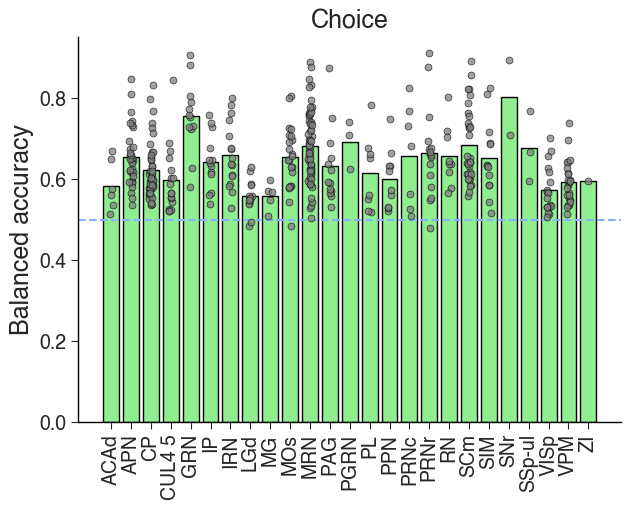

In [ ]:
# plot_accuracies(files_choice, "choice", region_names=region_names_choice, title="Choice")
# plt.savefig(
#     "../reports/figures/choice_decoder_all.png", dpi=300, bbox_inches="tight", facecolor="white"
# )

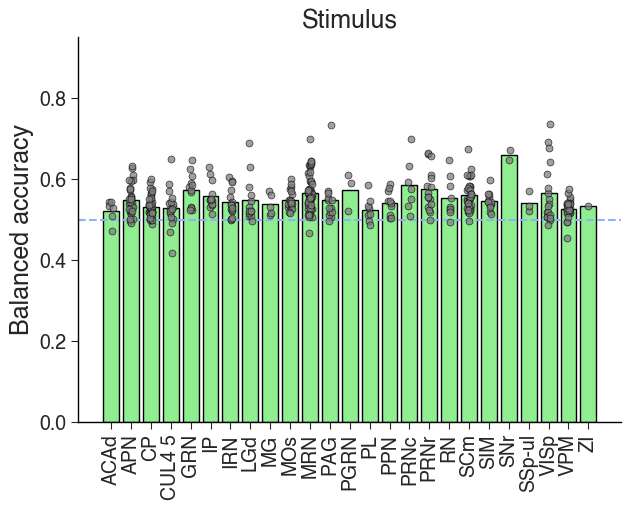

In [ ]:
# plot_accuracies(files_stim, "stim", region_names=region_names_stim, title="Stimulus")
# plt.savefig(
#     "../reports/figures/stimulus_decoder_all.png", dpi=300, bbox_inches="tight", facecolor="white"
# )

In [36]:
# plot_accuracies  only works with the one that has decoding results, not the recomputed ones

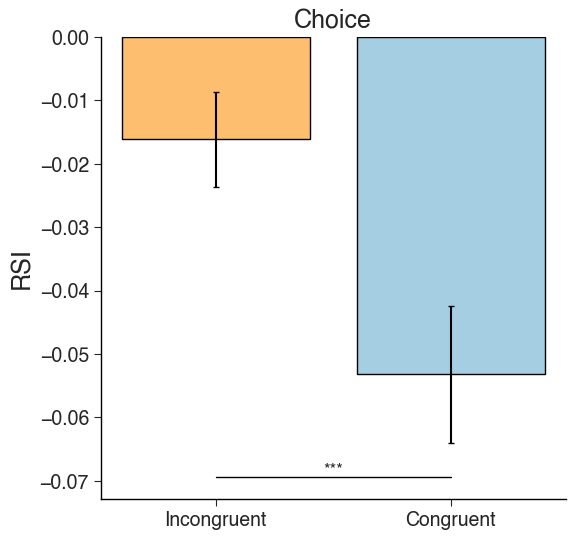

In [61]:
plot_all_rsis(rsi_congruent_choice, rsi_incongruent_choice, "Choice")
plt.savefig(
    "../reports/figures/choice_decoder_pid_all.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

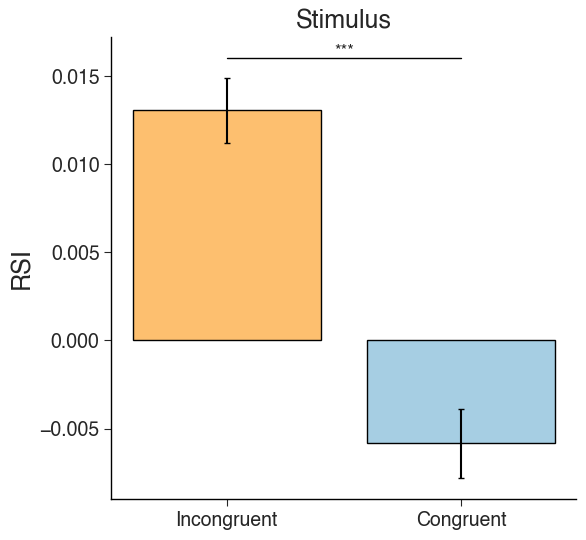

In [62]:
plot_all_rsis(rsi_congruent_stim, rsi_incongruent_stim, "Stimulus")
plt.savefig(
    "../reports/figures/stim_decoder_pid_all.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

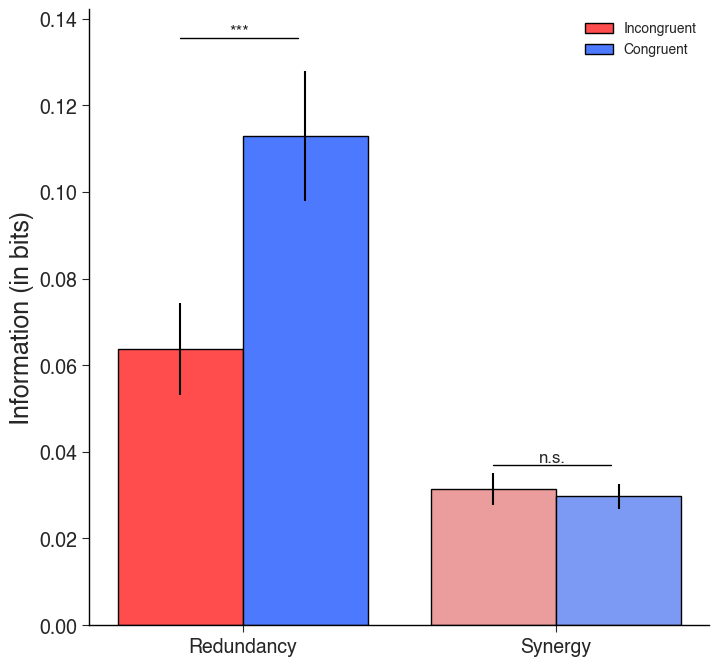

In [40]:
plot_all_decompositions(redundancy_choice, synergy_choice)

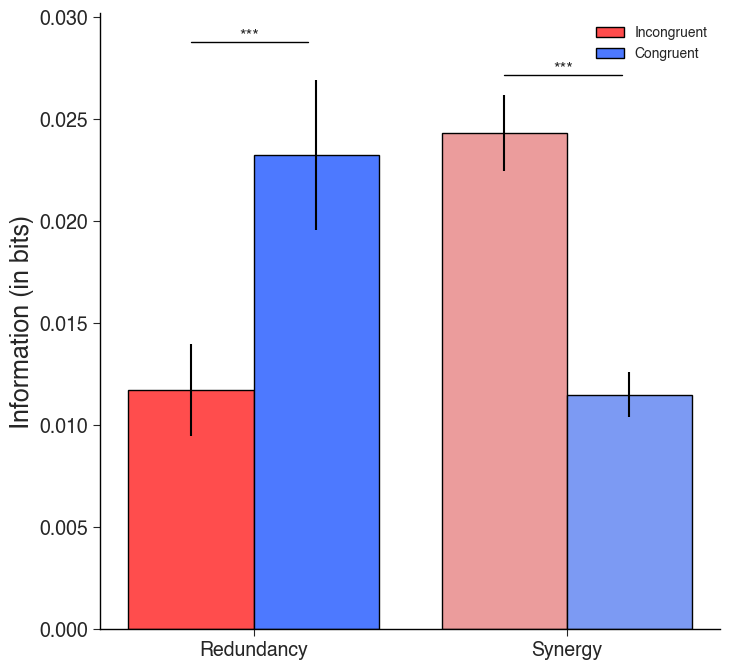

In [41]:
plot_all_decompositions(redundancy_stim, synergy_stim)

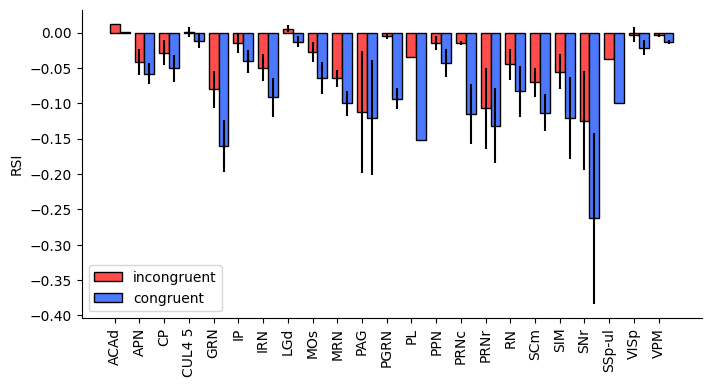

In [41]:
plot_regions_rsi(rsi_incongruent_choice, rsi_congruent_choice, region_names_choice)

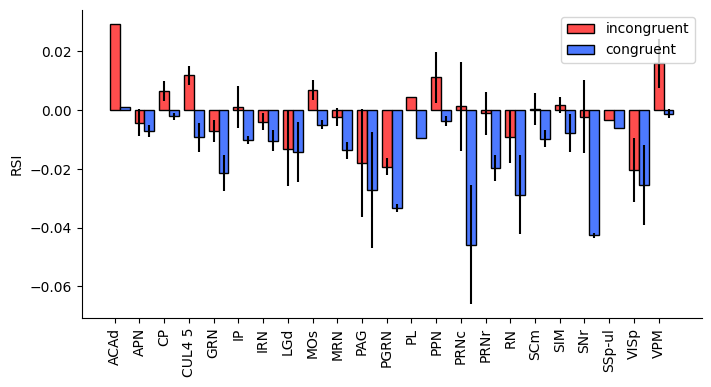

In [42]:
plot_regions_rsi(rsi_incongruent_stim, rsi_congruent_stim, region_names_stim)

In [23]:
# compute_deltas

In [12]:
# not really, we need to compute this for each animal

In [43]:
delta_congruent, delta_incongruent, region_names_delta = compute_deltas_all(
    files_choice, files_stim
)

Ey: MG, something is empty
Ey: ZI, something is empty


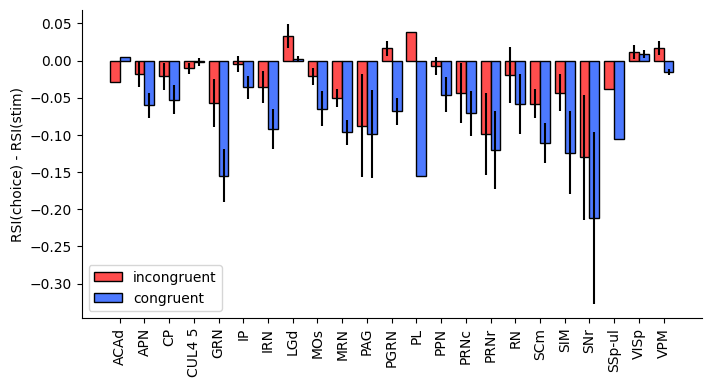

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.despine()

ax.bar(
    np.arange(len(delta_incongruent)),
    delta_incongruent[:, 0],
    yerr=delta_incongruent[:, 1],
    edgecolor="k",
    color="#FF4D4D",
    width=0.4,
    label="incongruent",
)
ax.bar(
    np.arange(len(delta_congruent)) + 0.4,
    delta_congruent[:, 0],
    yerr=delta_congruent[:, 1],
    edgecolor="k",
    color="#4D79FF",
    width=0.4,
    label="congruent",
)

ax.set_xticks(np.arange(len(region_names_delta)) + 0.2, region_names_delta, rotation=90)
ax.set_ylabel("RSI(choice) - RSI(stim)")
ax.legend()

### Check what's up with equipopulated

In [115]:
def collapse_animal_tvmi(animal):
    # the 7 is mia, mib, tvmi, unqa, unqb, red, syn
    animal_info = animal["information"]
    congruent_info = animal_info[:, 0, :]
    incongruent_info = animal_info[:, 1, :]
    return np.sum(congruent_info[:, 2] < 0) / 50, np.sum(incongruent_info[:, 2] < 0) / 50

In [134]:
filename = "../data/generated/pairwise_decoders/stim/goodsessions/equidistant_5bins/selective_decomposition_CP_stim_decoder_alldata_goodsessions_projections.pkl"

with open(filename, "rb") as f:
    data = pkl.load(f)

In [135]:
cinfo, incinfo = [], []
for k in data.keys():
    a, b = collapse_animal_tvmi(data[k])
    cinfo.append(a)
    incinfo.append(b)

In [132]:
filename_spaced = "../data/generated/pairwise_decoders/recomputed_both_epochs/recomputed_goodsessions/recomputed_CP_stim_equispaced_subset_3.pkl"

with open(filename_spaced, "rb") as f:
    data_spaced = pkl.load(f)

In [119]:
cinfo_spaced, incinfo_spaced = [], []
for k in data_spaced.keys():
    a, b = collapse_animal_tvmi(data_spaced[k])
    cinfo_spaced.append(a)
    incinfo_spaced.append(b)

In [124]:
np.mean(incinfo)

np.float64(0.55125)

In [125]:
np.mean(incinfo_spaced)

np.float64(0.355)

In [126]:
np.mean(cinfo)

np.float64(0.16499999999999998)

In [128]:
np.mean(cinfo_spaced)

np.float64(0.16)

In [154]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def analyze_smearing_congruent_vs_incongruent(cong_preds, incong_preds, n_bins=3):
    """
    Visualizes the 'Smearing' effect across bins, comparing Congruent vs Incongruent trials.

    Strategies Compared:
    1. Equispaced: Fixed semantic bins [0, 0.33, 0.66, 1.0]
    2. Pooled Equipopulated: Edges calculated on the COMBINED dataset (Congruent + Incongruent).
    """

    # 1. Define Edges
    # A. Equispaced
    edges_equal = np.linspace(0, 1, n_bins + 1)

    # B. Pooled Equipopulated (calculated on ALL data combined)
    all_preds = np.concatenate([cong_preds, incong_preds])
    edges_pooled = np.percentile(all_preds, np.linspace(0, 100, n_bins + 1))

    # Helper to bin and collect plot data
    def collect_plot_data(preds, condition_name):
        bins_equal = np.digitize(preds, edges_equal[1:-1])
        bins_pooled = np.digitize(preds, edges_pooled[1:-1])

        data_list = []
        for b in range(n_bins):
            # Equispaced Data in Bin b
            vals_eq = preds[bins_equal == b]
            for v in vals_eq:
                data_list.append(
                    {
                        "Bin": f"Bin {b}",
                        "Strategy": "Equispaced",
                        "Probability": v,
                        "Condition": condition_name,
                    }
                )

            # Pooled Data in Bin b
            vals_pool = preds[bins_pooled == b]
            for v in vals_pool:
                data_list.append(
                    {
                        "Bin": f"Bin {b}",
                        "Strategy": "Pooled",
                        "Probability": v,
                        "Condition": condition_name,
                    }
                )
        return data_list

    # Collect Data
    data_cong = collect_plot_data(cong_preds, "Congruent")
    data_incong = collect_plot_data(incong_preds, "Incongruent")

    df = pd.DataFrame(data_cong + data_incong)

    # --- PLOTTING ---
    fig, axes = plt.subplots(2, n_bins, figsize=(5 * n_bins, 10), sharey=True)
    pal = {"Equispaced": "blue", "Pooled": "red"}

    conditions = ["Congruent", "Incongruent"]

    for row_idx, cond in enumerate(conditions):
        for col_idx in range(n_bins):
            bin_label = f"Bin {col_idx}"
            ax = axes[row_idx, col_idx]

            # Filter Data
            subset = df[(df["Condition"] == cond) & (df["Bin"] == bin_label)]

            if not subset.empty:
                # Strip plot for raw data points
                sns.stripplot(
                    data=subset,
                    x="Strategy",
                    y="Probability",
                    hue="Strategy",
                    palette=pal,
                    ax=ax,
                    alpha=0.4,
                    jitter=0.2,
                    legend=False,
                )

                # Box plot for distribution summary
                sns.boxplot(
                    data=subset,
                    x="Strategy",
                    y="Probability",
                    hue="Strategy",
                    palette=pal,
                    ax=ax,
                    width=0.3,
                    showfliers=False,
                )
                if ax.legend_:
                    ax.legend_.remove()

            # Draw Ideal Zones (Equispaced Reference Background)
            ideal_bottom = edges_equal[col_idx]
            ideal_top = edges_equal[col_idx + 1]
            ax.axhspan(ideal_bottom, ideal_top, color="blue", alpha=0.05)
            ax.axhline(ideal_bottom, color="blue", linestyle="--", alpha=0.3)
            ax.axhline(ideal_top, color="blue", linestyle="--", alpha=0.3)

            # Titles/Labels
            if row_idx == 0:
                ax.set_title(f"{bin_label}\n(Congruent Trials)", fontweight="bold")
            else:
                ax.set_title(f"{bin_label}\n(Incongruent Trials)", fontweight="bold")

            ax.set_ylim(-0.05, 1.05)
            ax.set_xlabel("")
            if col_idx == 0:
                ax.set_ylabel("Decoder Probability Output")
            else:
                ax.set_ylabel("")

    plt.tight_layout()
    sns.despine()
    plt.show()

In [165]:
x = data["0cbeae00-e229-4b7d-bdcc-1b0569d7e0c3"]["decoding_results"][2]

In [167]:
x = data["0cbeae00-e229-4b7d-bdcc-1b0569d7e0c3"]["decoding_results"][2]

In [168]:
x["accuracy_B_cong"]

0.5732647814910026

In [169]:
x["accuracy_B_incong"]

0.4819277108433735